# Kilian (2007) Dataset: Bayesian VAR Replication

This notebook duplicates the original data workflow but estimates a Bayesian VAR with NIW prior and Gibbs sampling.

## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import invwishart
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import VAR
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(suppress=True, precision=4)

BASE_DIR = Path('..')

## Load the Kilian VAR data

In [ ]:


data = np.loadtxt(BASE_DIR / 'data/old_data.txt')
cols = ['d_prod', 'rea', 'rpo']
df = pd.DataFrame(data, columns=cols)
df.head(), df.shape

(      d_prod        rea        rpo
 0  11.877264  36.064235 -47.999534
 1   1.419150  41.527016 -48.286474
 2   1.177711  43.991250 -47.082500
 3  27.455136  48.105889 -43.857651
 4 -13.110436  52.033462 -41.571063,
 (419, 3))

## Data Summary and diagnostics



In [3]:
print(df.describe())
print(df.isnull().sum())
print(df.isna().sum())


           d_prod         rea         rpo
count  419.000000  419.000000  419.000000
mean     0.889630    0.184575    0.112886
std     20.522868   24.113565   45.659460
min   -118.887490  -47.388655 -114.779490
25%     -6.736792  -16.884864  -36.516812
50%      2.459362   -5.849393  -10.448920
75%     10.103779   12.469477   36.939739
max     77.983205   76.712093   90.636602
d_prod    0
rea       0
rpo       0
dtype: int64
d_prod    0
rea       0
rpo       0
dtype: int64


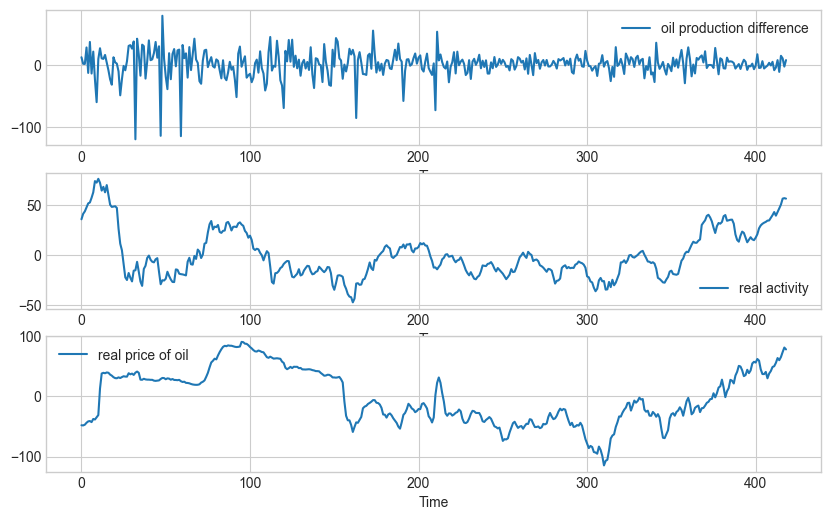

In [ ]:
plt.figure(figsize=(10, 6)) 
# arrange the plot in a 3x1 grid
plt.subplot(3, 1, 1)
plt.plot(df['d_prod'], label='oil production difference')
plt.xlabel('Time')
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(df['rea'], label='real activity')
plt.xlabel('Time')
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(df['rpo'], label='real price of oil', color='red')
plt.xlabel('Time')
plt.legend()
plt.show()

## Stationarity checks (ADF and KPSS)

In [5]:
rows = []
for c in cols:
    s = df[c].dropna().values
    adf = adfuller(s, regression='c', autolag='AIC')
    kps = kpss(s, regression='c', nlags='auto')
    rows.append({
        'series': c,
        'adf_stat': adf[0],
        'adf_pvalue': adf[1],
        'kpss_stat': kps[0],
        'kpss_pvalue': kps[1]
    })
stationarity_table = pd.DataFrame(rows)
stationarity_table

/var/folders/3g/9jy95tfs3s11qr_9lw9l2dsm0000gn/T/ipykernel_99048/922127869.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kps = kpss(s, regression='c', nlags='auto')
/var/folders/3g/9jy95tfs3s11qr_9lw9l2dsm0000gn/T/ipykernel_99048/922127869.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kps = kpss(s, regression='c', nlags='auto')
/var/folders/3g/9jy95tfs3s11qr_9lw9l2dsm0000gn/T/ipykernel_99048/922127869.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kps = kpss(s, regression='c', nlags='auto')


,series,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue
0,d_prod,-4.703995,0.000083,0.070289,0.10
1,rea,-3.419471,0.010313,0.319072,0.10
2,rpo,-1.952607,0.307732,1.012888,0.01


## AIC table by lag length

In [6]:
aic_rows = []
for lag in range(1, 37):
    try:
        res = VAR(df).fit(lag)
        aic_rows.append({'lag': lag, 'AIC': res.aic})
    except Exception:
        aic_rows.append({'lag': lag, 'AIC': np.nan})
aic_table = pd.DataFrame(aic_rows)
aic_table

,lag,AIC
0,1,13.037877
1,2,12.770210
2,3,12.750283
3,4,12.773022
4,5,12.786172
5,6,12.811331
6,7,12.795431
7,8,12.806773
8,9,12.814339
9,10,12.828683


## BVAR(24) with NIW prior and Gibbs sampling

In [7]:
p = 24
n_draws = 12000
burn = 2000

bvar = gibbs_bvar_niw(df.values, p=p, n_draws=n_draws, burn=burn, seed=42)
bvar['B_mean'].shape, bvar['Sigma_mean']

((73, 3),
 array([[285.624 ,   1.1244,  -6.7227],
        [  1.1244,  13.3979,   1.5405],
        [ -6.7227,   1.5405,  29.0644]]))

## MCMC trace plots (visual convergence check)

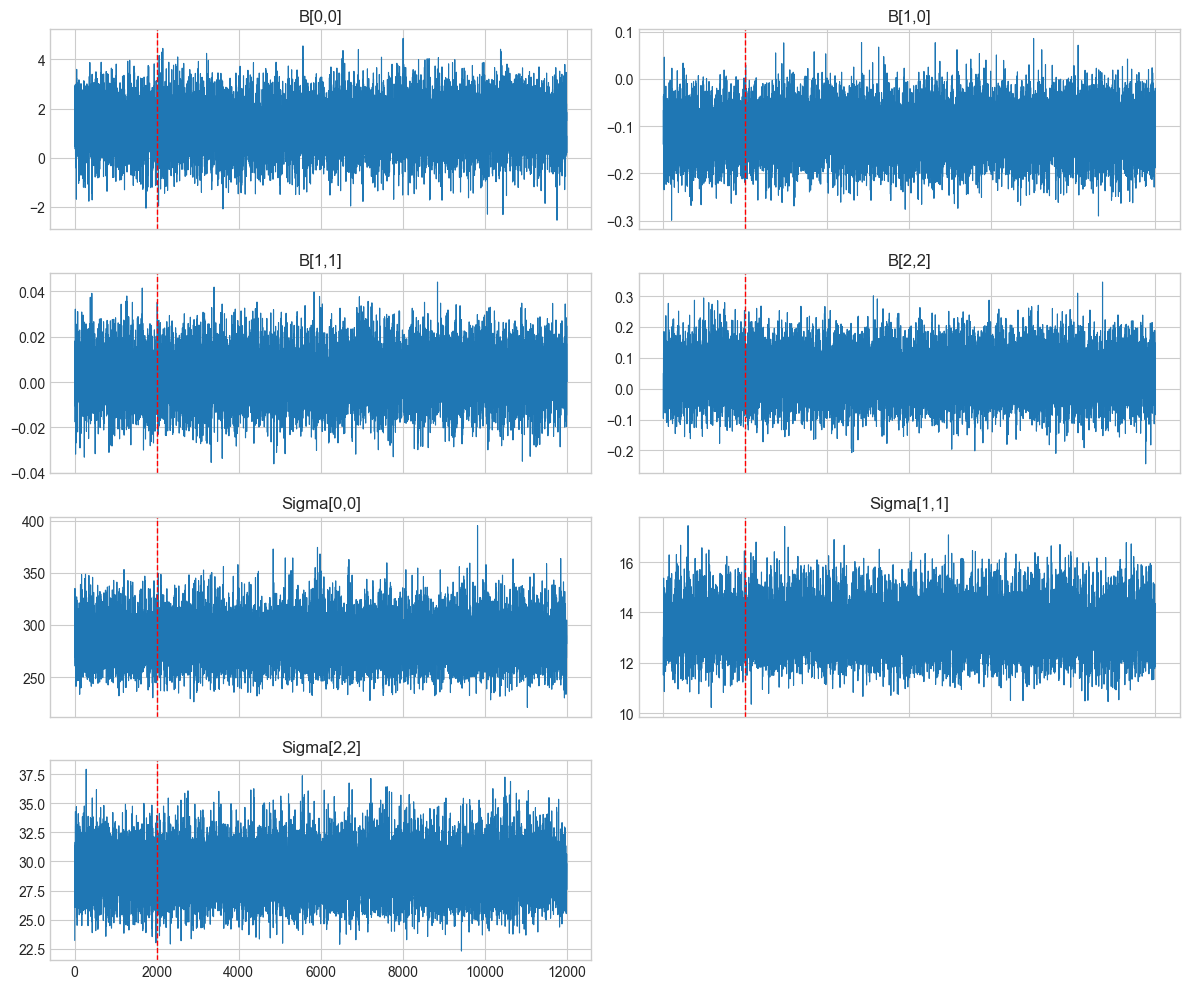

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()

trace_names = ['B[0,0]', 'B[1,0]', 'B[1,1]', 'B[2,2]']
for i in range(4):
    axes[i].plot(bvar['B_trace'][:, i], lw=0.8)
    axes[i].axvline(2000, color='r', ls='--', lw=1)
    axes[i].set_title(trace_names[i])

sig_names = ['Sigma[0,0]', 'Sigma[1,1]', 'Sigma[2,2]']
for i in range(3):
    axes[4+i].plot(bvar['S_trace'][:, i], lw=0.8)
    axes[4+i].axvline(2000, color='r', ls='--', lw=1)
    axes[4+i].set_title(sig_names[i])

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Residual diagnostics (Ljung-Box test)

In [9]:
Y = bvar['Y']
X = bvar['X']
Bhat = bvar['B_mean']
resid = Y - X @ Bhat

lb_rows = []
for i, c in enumerate(cols):
    lb = acorr_ljungbox(resid[:, i], lags=[12], return_df=True)
    lb_rows.append({
        'series': c,
        'lb_stat_lag12': float(lb['lb_stat'].iloc[0]),
        'lb_pvalue_lag12': float(lb['lb_pvalue'].iloc[0])
    })
ljung_box_table = pd.DataFrame(lb_rows)
ljung_box_table

,series,lb_stat_lag12,lb_pvalue_lag12
0,d_prod,3.183459,0.994104
1,rea,4.317556,0.977001
2,rpo,0.853983,0.999994


## Running posterior mean over iterations

This plots the cumulative posterior mean (after burn-in) to visually inspect stabilization over MCMC draws.

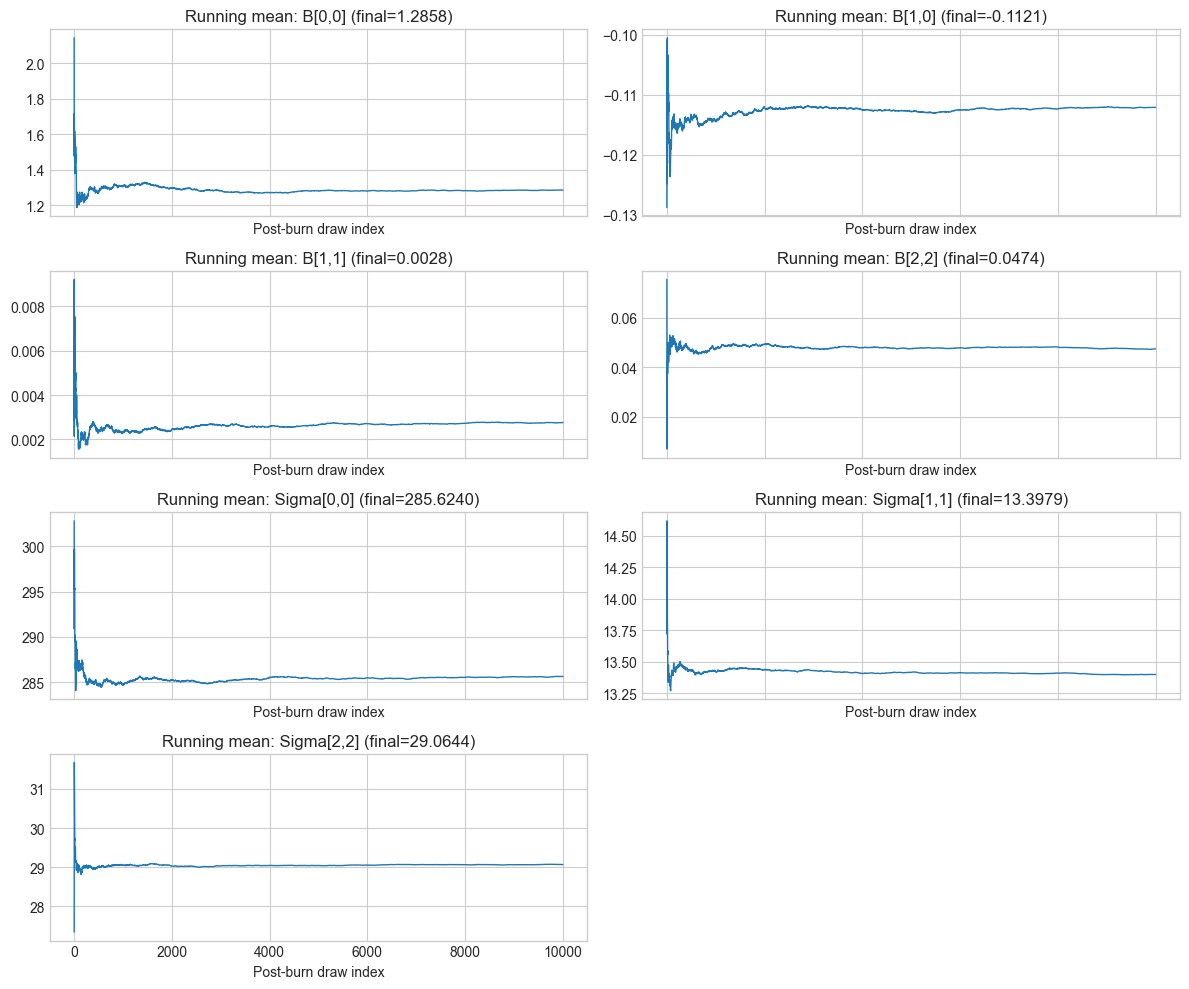

In [10]:
keep_B = bvar['B_draws']
keep_S = bvar['Sigma_draws']

cum_mean_B00 = np.cumsum(keep_B[:, 0, 0]) / np.arange(1, keep_B.shape[0] + 1)
cum_mean_B10 = np.cumsum(keep_B[:, 1, 0]) / np.arange(1, keep_B.shape[0] + 1)
cum_mean_B11 = np.cumsum(keep_B[:, 1, 1]) / np.arange(1, keep_B.shape[0] + 1)
cum_mean_B22 = np.cumsum(keep_B[:, 2, 2]) / np.arange(1, keep_B.shape[0] + 1)

cum_mean_S00 = np.cumsum(keep_S[:, 0, 0]) / np.arange(1, keep_S.shape[0] + 1)
cum_mean_S11 = np.cumsum(keep_S[:, 1, 1]) / np.arange(1, keep_S.shape[0] + 1)
cum_mean_S22 = np.cumsum(keep_S[:, 2, 2]) / np.arange(1, keep_S.shape[0] + 1)

fig, axes = plt.subplots(4, 2, figsize=(12, 10), sharex=True)
axes = axes.ravel()

series = [
    (cum_mean_B00, 'Running mean: B[0,0]'),
    (cum_mean_B10, 'Running mean: B[1,0]'),
    (cum_mean_B11, 'Running mean: B[1,1]'),
    (cum_mean_B22, 'Running mean: B[2,2]'),
    (cum_mean_S00, 'Running mean: Sigma[0,0]'),
    (cum_mean_S11, 'Running mean: Sigma[1,1]'),
    (cum_mean_S22, 'Running mean: Sigma[2,2]'),
]

for i, (s, ttl) in enumerate(series):
    axes[i].plot(s, lw=1)
    axes[i].set_title(f"{ttl} (final={s[-1]:.4f})")
    axes[i].set_xlabel('Post-burn draw index')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

## Bayesian Figure 2: structural shocks (posterior mean parameters)

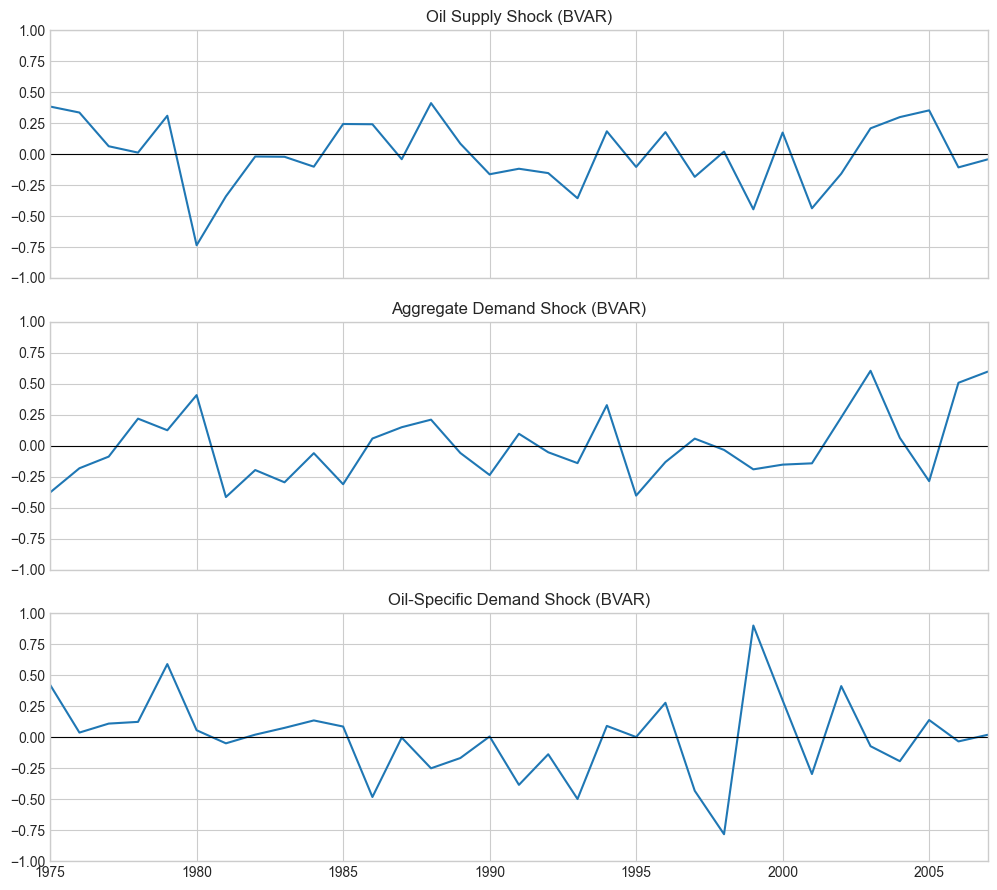

In [11]:
p = 24
n = 3
h = 15

y = df.values
Ehat_b = structural_shocks_from_bmean(y, bvar['B_mean'], bvar['Sigma_mean'], p=p)

q1 = np.concatenate([[(Ehat_b[0, 0] + Ehat_b[0, 1]) / 2], Ehat_b[0, :]])
q2 = np.concatenate([[(Ehat_b[1, 0] + Ehat_b[1, 1]) / 2], Ehat_b[1, :]])
q3 = np.concatenate([[(Ehat_b[2, 0] + Ehat_b[2, 1]) / 2], Ehat_b[2, :]])

time_year = np.arange(1975, 2007 + 1)
q1a = q1[:len(time_year) * 12].reshape(-1, 12).mean(axis=1)
q2a = q2[:len(time_year) * 12].reshape(-1, 12).mean(axis=1)
q3a = q3[:len(time_year) * 12].reshape(-1, 12).mean(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
for ax, s, ttl in zip(
    axes,
    [q1a, q2a, q3a],
    ['Oil Supply Shock (BVAR)', 'Aggregate Demand Shock (BVAR)', 'Oil-Specific Demand Shock (BVAR)']
):
    ax.plot(time_year, s)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xlim(1975, 2007)
    ax.set_ylim(-1, 1)
    ax.set_title(ttl)

plt.tight_layout()
plt.show()

## Bayesian Figure 3: IRFs and credible intervals from posterior draws

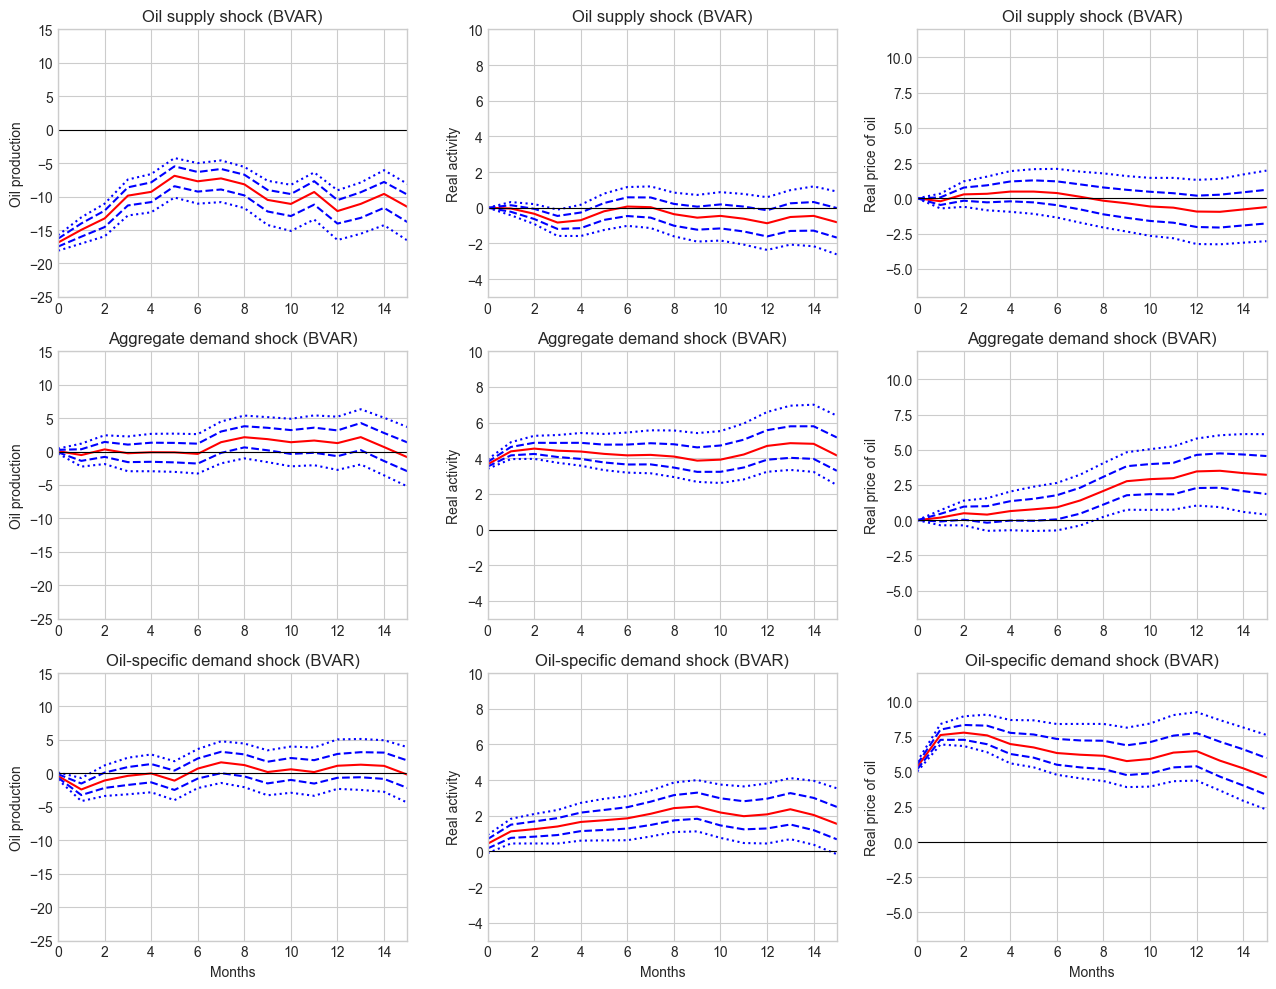

In [12]:
# Posterior draw IRFs for credible bands
n_keep = bvar['B_draws'].shape[0]
max_draws = min(2000, n_keep)
idx = np.linspace(0, n_keep - 1, max_draws, dtype=int)

IRF_draws = np.zeros((max_draws, n * n, h + 1))
for j, d in enumerate(idx):
    B_d = bvar['B_draws'][d]
    S_d = bvar['Sigma_draws'][d]
    _, _, A_comp_d = bvar_state_matrices(B_d, n=n, p=p)
    irf_d = irf_from_companion(A_comp_d, S_d, n=n, p=p, h=h)
    irf_d[0, :] = np.cumsum(irf_d[0, :])
    irf_d[3, :] = np.cumsum(irf_d[3, :])
    irf_d[6, :] = np.cumsum(irf_d[6, :])
    IRF_draws[j] = irf_d

IRF_med = np.median(IRF_draws, axis=0)
IRF_68 = np.quantile(IRF_draws, [0.16, 0.84], axis=0)
IRF_95 = np.quantile(IRF_draws, [0.025, 0.975], axis=0)

horizon = np.arange(0, h + 1)
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.ravel()

meta = [
    ('Oil supply shock (BVAR)', 'Oil production', (-25, 15), -1),
    ('Oil supply shock (BVAR)', 'Real activity', (-5, 10), -1),
    ('Oil supply shock (BVAR)', 'Real price of oil', (-7, 12), -1),
    ('Aggregate demand shock (BVAR)', 'Oil production', (-25, 15), 1),
    ('Aggregate demand shock (BVAR)', 'Real activity', (-5, 10), 1),
    ('Aggregate demand shock (BVAR)', 'Real price of oil', (-7, 12), 1),
    ('Oil-specific demand shock (BVAR)', 'Oil production', (-25, 15), 1),
    ('Oil-specific demand shock (BVAR)', 'Real activity', (-5, 10), 1),
    ('Oil-specific demand shock (BVAR)', 'Real price of oil', (-7, 12), 1),
]

for i, (ttl, yl, ylim, sgn) in enumerate(meta):
    ax = axes[i]
    m = sgn * IRF_med[i]
    l68, u68 = sgn * IRF_68[0, i], sgn * IRF_68[1, i]
    l95, u95 = sgn * IRF_95[0, i], sgn * IRF_95[1, i]
    lo68, hi68 = np.minimum(l68, u68), np.maximum(l68, u68)
    lo95, hi95 = np.minimum(l95, u95), np.maximum(l95, u95)

    ax.plot(horizon, m, 'r-')
    ax.plot(horizon, lo68, 'b--')
    ax.plot(horizon, hi68, 'b--')
    ax.plot(horizon, lo95, 'b:')
    ax.plot(horizon, hi95, 'b:')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(ttl)
    ax.set_ylabel(yl)
    ax.set_xlim(0, h)
    ax.set_ylim(*ylim)
    if i >= 6:
        ax.set_xlabel('Months')

plt.tight_layout()
plt.show()

# 4.1 FEVD

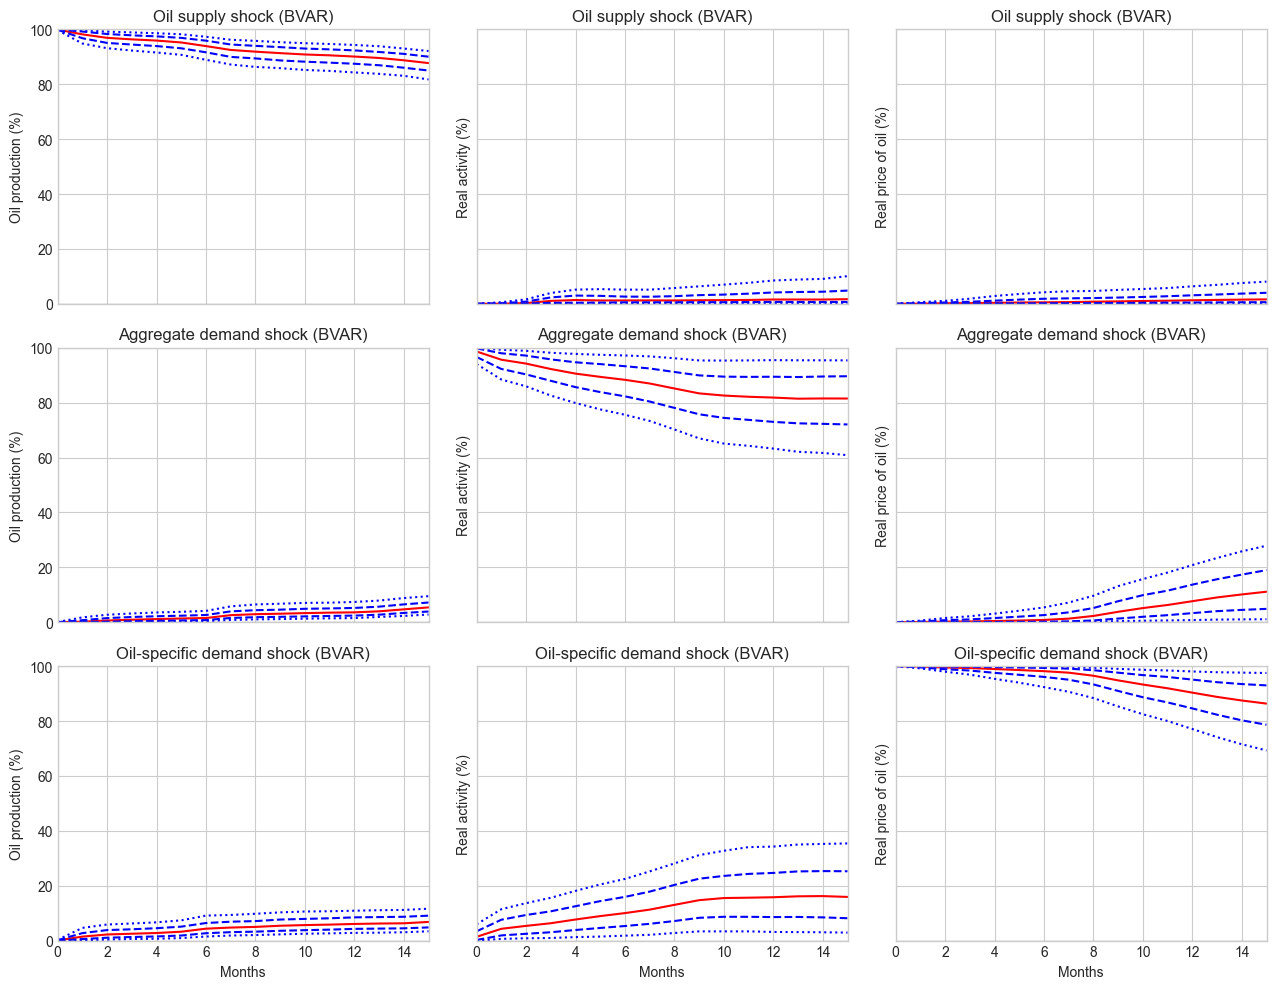

FEVD verification (should sum to ~100% for each variable at each horizon):
Oil production: h=0: 100.0%, h=6: 99.7%, h=15: 99.9%
Real activity: h=0: 100.0%, h=6: 99.5%, h=15: 99.1%
Real price of oil: h=0: 100.0%, h=6: 99.5%, h=15: 99.1%


In [17]:
# FEVD: posterior draws + credible bands
n_keep = bvar['B_draws'].shape[0]
max_draws = min(2000, n_keep)
idx = np.linspace(0, n_keep - 1, max_draws, dtype=int)

# FEVD_draws[d, shock, variable, horizon]
FEVD_draws = np.zeros((max_draws, n, n, h + 1))

for j, d in enumerate(idx):
    B_d = bvar['B_draws'][d]
    S_d = bvar['Sigma_draws'][d]
    _, _, A_comp_d = bvar_state_matrices(B_d, n=n, p=p)
    irf_d = irf_from_companion(A_comp_d, S_d, n=n, p=p, h=h)

    # irf_d uses order='F': [var1_shock1, var2_shock1, var3_shock1, var1_shock2, ...]
    # Reshape to (variable, shock, horizon) then transpose to (shock, variable, horizon)
    psi = irf_d.reshape(n, n, h + 1, order='F').transpose(1, 0, 2)

    # cumulative squared impulse responses up to horizon t
    cum_sq = np.cumsum(psi ** 2, axis=2)
    denom = np.sum(cum_sq, axis=0, keepdims=True)

    # avoid divide-by-zero at very early horizons
    FEVD_draws[j] = np.divide(cum_sq, denom, out=np.zeros_like(cum_sq), where=denom > 0)

FEVD_med = np.median(FEVD_draws, axis=0)
FEVD_68 = np.quantile(FEVD_draws, [0.16, 0.84], axis=0)
FEVD_95 = np.quantile(FEVD_draws, [0.025, 0.975], axis=0)

horizon = np.arange(0, h + 1)
fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharex=True, sharey=True)
axes = axes.ravel()

meta = [
    ('Oil supply shock (BVAR)', 'Oil production'),
    ('Oil supply shock (BVAR)', 'Real activity'),
    ('Oil supply shock (BVAR)', 'Real price of oil'),
    ('Aggregate demand shock (BVAR)', 'Oil production'),
    ('Aggregate demand shock (BVAR)', 'Real activity'),
    ('Aggregate demand shock (BVAR)', 'Real price of oil'),
    ('Oil-specific demand shock (BVAR)', 'Oil production'),
    ('Oil-specific demand shock (BVAR)', 'Real activity'),
    ('Oil-specific demand shock (BVAR)', 'Real price of oil'),
]

for k, (ttl, yl) in enumerate(meta):
    shock = k // n
    var = k % n

    med = 100.0 * FEVD_med[shock, var]
    l68 = 100.0 * FEVD_68[0, shock, var]
    u68 = 100.0 * FEVD_68[1, shock, var]
    l95 = 100.0 * FEVD_95[0, shock, var]
    u95 = 100.0 * FEVD_95[1, shock, var]

    lo68, hi68 = np.minimum(l68, u68), np.maximum(l68, u68)
    lo95, hi95 = np.minimum(l95, u95), np.maximum(l95, u95)

    ax = axes[k]
    ax.plot(horizon, med, 'r-')
    ax.plot(horizon, lo68, 'b--')
    ax.plot(horizon, hi68, 'b--')
    ax.plot(horizon, lo95, 'b:')
    ax.plot(horizon, hi95, 'b:')
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(ttl)
    ax.set_ylabel(f"{yl} (%)")
    ax.set_xlim(0, h)
    ax.set_ylim(0, 100)
    if k >= 6:
        ax.set_xlabel('Months')

plt.tight_layout()
plt.show()

# Verification: FEVD should sum to 100% across shocks for each variable
print("FEVD verification (should sum to ~100% for each variable at each horizon):")
for var in range(n):
    var_names = ['Oil production', 'Real activity', 'Real price of oil']
    fevd_sum = np.sum(FEVD_med[:, var, :], axis=0) * 100
    print(f"{var_names[var]}: h=0: {fevd_sum[0]:.1f}%, h=6: {fevd_sum[6]:.1f}%, h=15: {fevd_sum[15]:.1f}%")


In [18]:
# Granger causality tests (lag p=24, same as BVAR)
from IPython.display import display
from statsmodels.tsa.stattools import grangercausalitytests

var_names = ['d_prod', 'rea', 'rpo']
var_labels = {
    'd_prod': 'oil production (d_prod)',
    'rea': 'real activity (rea)',
    'rpo': 'real price of oil (rpo)',
}

# Bivariate tests: H0 = x does NOT Granger-cause y
# statsmodels: column 2 Granger-causes column 1 in [y, x]
bivariate_tests = [
    ('rea', 'd_prod', 'd_prod → rea'),
    ('rpo', 'd_prod', 'd_prod → rpo'),
    ('d_prod', 'rea', 'rea → d_prod'),
    ('rpo', 'rea', 'rea → rpo'),
    ('rea', 'rpo', 'rpo → rea'),
    ('d_prod', 'rpo', 'rpo → d_prod'),
]

bi_rows = []
for y_col, x_col, label in bivariate_tests:
    arr = df[[y_col, x_col]].values
    res = grangercausalitytests(arr, maxlag=[p], verbose=False)
    fstat, pval, df_denom, df_num = res[p][0]['ssr_ftest']
    bi_rows.append({
        'direction': label,
        'cause': var_labels[x_col],
        'effect': var_labels[y_col],
        'F_stat': fstat,
        'p_value': pval,
        'reject_5pct': pval < 0.05,
    })

bivariate_gc = pd.DataFrame(bi_rows)
print('Bivariate Granger causality (H0: no causality):')
display(bivariate_gc.style.format({'F_stat': '{:.3f}', 'p_value': '{:.4f}'}))

# Multivariate tests: H0 = lags of "cause" do not help predict all other variables
var_ols = VAR(df[var_names]).fit(p)
mv_rows = []
for cause in var_names:
    caused = [c for c in var_names if c != cause]
    tc = var_ols.test_causality(caused=caused, causing=cause)
    mv_rows.append({
        'cause': var_labels[cause],
        'effect': 'all other variables',
        'F_stat': tc.test_statistic,
        'p_value': tc.pvalue,
        'reject_5pct': tc.pvalue < 0.05,
    })

multivariate_gc = pd.DataFrame(mv_rows)
print('\nMultivariate Granger causality (conditional on full VAR):')
display(multivariate_gc.style.format({'F_stat': '{:.3f}', 'p_value': '{:.4f}'}))

# Pairwise FEVD at h=15 for comparison (median across posterior draws if FEVD_med exists)
if 'FEVD_med' in globals():
    h_fevd = FEVD_med.shape[2] - 1
    fevd_h = 100 * FEVD_med[:, :, h_fevd]
    fevd_diag = pd.Series(
        {var_labels[var_names[i]]: fevd_h[i, i] for i in range(n)},
        name=f'own-shock FEVD at h={h_fevd} (%)',
    )
    print(f'\nDiagonal FEVD shares at horizon h={h_fevd} (posterior median):')
    display(fevd_diag.to_frame())


Bivariate Granger causality (H0: no causality):


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since fu

,direction,cause,effect,F_stat,p_value,reject_5pct
0,d_prod → rea,oil production (d_prod),real activity (rea),1.539,0.0526,False
1,d_prod → rpo,oil production (d_prod),real price of oil (rpo),0.603,0.9315,False
2,rea → d_prod,real activity (rea),oil production (d_prod),1.992,0.0042,True
3,rea → rpo,real activity (rea),real price of oil (rpo),1.143,0.2938,False
4,rpo → rea,real price of oil (rpo),real activity (rea),1.497,0.0648,False
5,rpo → d_prod,real price of oil (rpo),oil production (d_prod),0.802,0.7344,False



Multivariate Granger causality (conditional on full VAR):


,cause,effect,F_stat,p_value,reject_5pct
0,oil production (d_prod),all other variables,1.284,0.0965,False
1,real activity (rea),all other variables,1.713,0.0022,True
2,real price of oil (rpo),all other variables,1.456,0.0248,True



Diagonal FEVD shares at horizon h=15 (posterior median):


,own-shock FEVD at h=15 (%)
oil production (d_prod),87.702773
real activity (rea),81.494953
real price of oil (rpo),86.341724


## Bayesian Figure 4: cumulative effect on real oil price

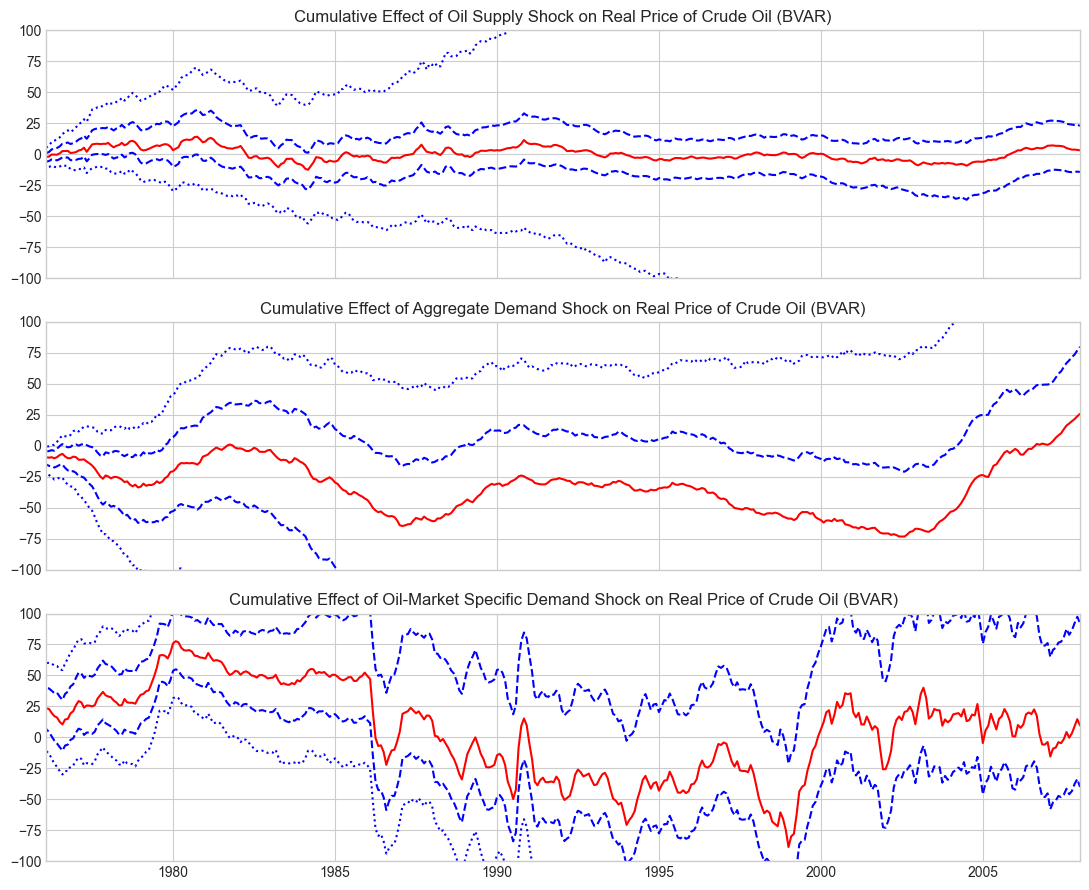

In [14]:
oil_ci = posterior_draw_CI(y, bvar['B_draws'], bvar['Sigma_draws'], p=p, n=n)

time = np.arange(1975 + 2 / 12, 2007 + 12 / 12 + 1e-9, 1 / 12)
titles = [
    'Cumulative Effect of Oil Supply Shock on Real Price of Crude Oil (BVAR)',
    'Cumulative Effect of Aggregate Demand Shock on Real Price of Crude Oil (BVAR)',
    'Cumulative Effect of Oil-Market Specific Demand Shock on Real Price of Crude Oil (BVAR)',
]

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for shock, ax in enumerate(axes):
    m = oil_ci['median'][shock]
    l68, u68 = oil_ci['q68'][0, shock], oil_ci['q68'][1, shock]
    l95, u95 = oil_ci['q95'][0, shock], oil_ci['q95'][1, shock]
    lo68, hi68 = np.minimum(l68, u68), np.maximum(l68, u68)
    lo95, hi95 = np.minimum(l95, u95), np.maximum(l95, u95)

    ax.plot(time, m, 'r-')
    ax.plot(time, lo68, 'b--')
    ax.plot(time, hi68, 'b--')
    ax.plot(time, lo95, 'b:')
    ax.plot(time, hi95, 'b:')
    ax.set_title(titles[shock])
    ax.set_xlim(1976 + 1 / 12, 2007 + 12 / 12)
    ax.set_ylim(-100, 100)

plt.tight_layout()
plt.show()


## Bayesian Figure 5-style responses: shocks on real GDP and CPI

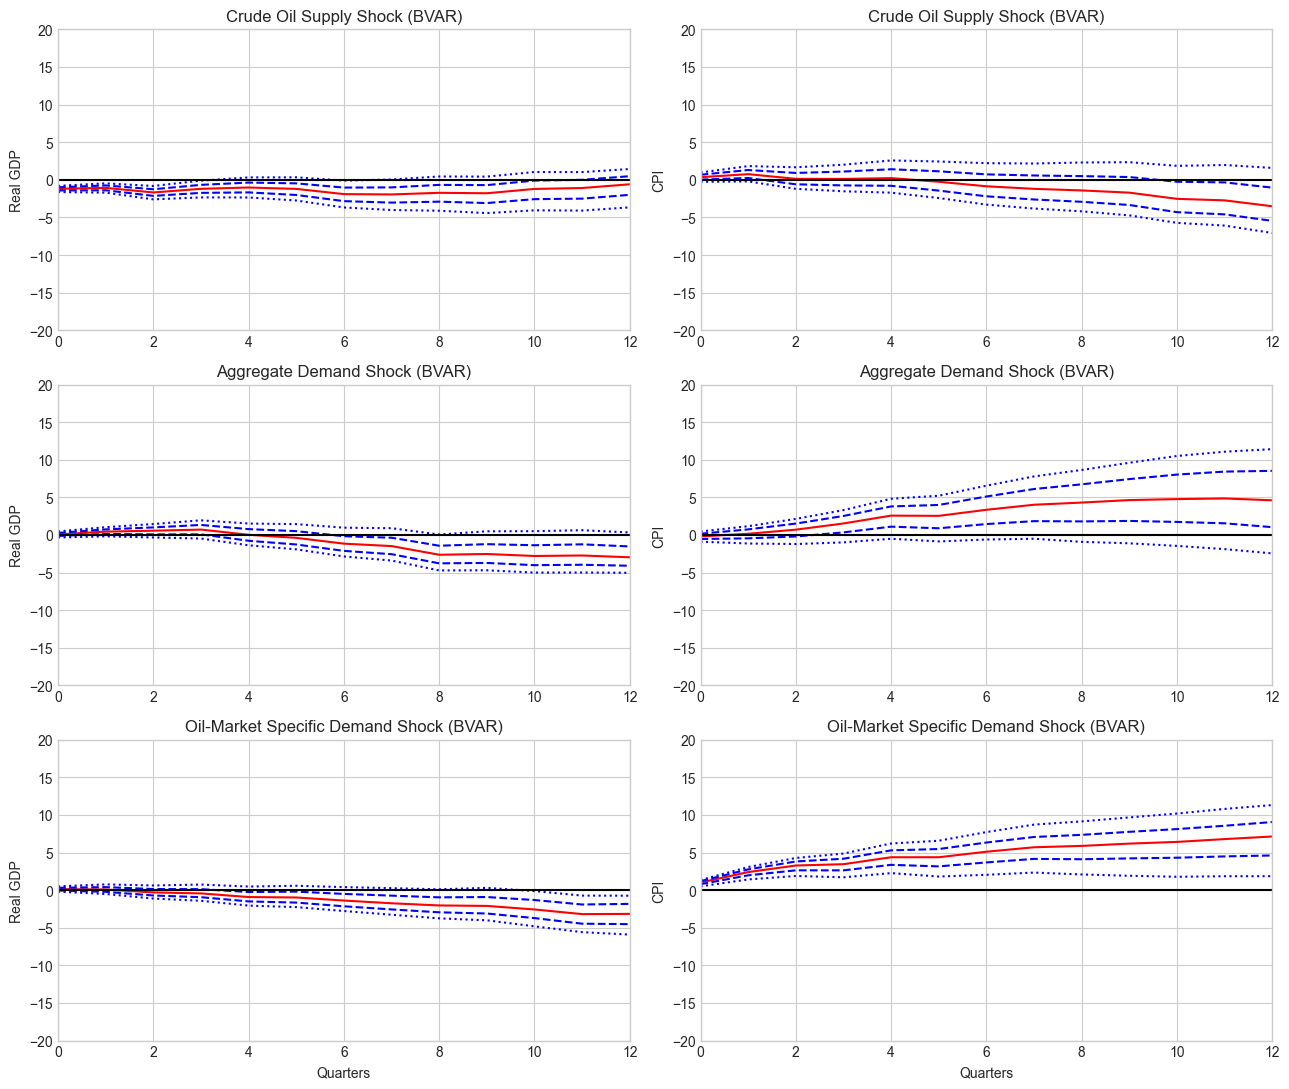

In [15]:
# Quarterly average structural shocks from BVAR (posterior mean, for reference series)
q1 = np.concatenate([[(Ehat_b[0, 0] + Ehat_b[0, 1]) / 2], Ehat_b[0, :]])
q2 = np.concatenate([[(Ehat_b[1, 0] + Ehat_b[1, 1]) / 2], Ehat_b[1, :]])
q3 = np.concatenate([[(Ehat_b[2, 0] + Ehat_b[2, 1]) / 2], Ehat_b[2, :]])

quarter_time = np.arange(1975 + 1 / 4, 2007 + 4 / 4 + 1e-9, 1 / 4)
nq = len(quarter_time)
q1q = q1[:3 * nq].reshape(-1, 3).mean(axis=1)
q2q = q2[:3 * nq].reshape(-1, 3).mean(axis=1)
q3q = q3[:3 * nq].reshape(-1, 3).mean(axis=1)

# GDP series
beagdp = np.loadtxt(BASE_DIR / 'data/beagdp.txt')
gdp = beagdp[:, 2]
y_gdp = (np.log(gdp[1:]) - np.log(gdp[:-1]))[:, None] * 400

# CPI inflation series
cpi_raw = np.loadtxt(BASE_DIR / 'data/cpi.txt')
cpi = np.log(cpi_raw[:, 2])
infl = np.array([(cpi[3 * i] - cpi[3 * (i - 1)]) * 400 for i in range(1, len(quarter_time) + 1)])
y_cpi = infl[:, None]

# Stage-2 responses: posterior credible bands (reuses Ehat_draws from oil_ci)
if 'oil_ci' not in globals():
    oil_ci = posterior_draw_CI(y, bvar['B_draws'], bvar['Sigma_draws'], p=p, n=n)

Ehat_draws = oil_ci['Ehat_draws']
r2 = stage2_posterior_ci(y_gdp, Ehat_draws, shock_idx=0, nq=nq)
r3 = stage2_posterior_ci(y_gdp, Ehat_draws, shock_idx=1, nq=nq)
r4 = stage2_posterior_ci(y_gdp, Ehat_draws, shock_idx=2, nq=nq)

c2 = stage2_posterior_ci(y_cpi, Ehat_draws, shock_idx=0, nq=nq)
c3 = stage2_posterior_ci(y_cpi, Ehat_draws, shock_idx=1, nq=nq)
c4 = stage2_posterior_ci(y_cpi, Ehat_draws, shock_idx=2, nq=nq)

h2 = np.arange(13)
fig, axes = plt.subplots(3, 2, figsize=(13, 11))

# GDP panels
for ax, rr, ttl, sgn in [
    (axes[0, 0], r2, 'Crude Oil Supply Shock (BVAR)', -1),
    (axes[1, 0], r3, 'Aggregate Demand Shock (BVAR)', 1),
    (axes[2, 0], r4, 'Oil-Market Specific Demand Shock (BVAR)', 1),
]:
    m = sgn * rr['cum']
    lo68 = sgn * rr['cum_68'][0]
    hi68 = sgn * rr['cum_68'][1]
    lo95 = sgn * rr['cum_95'][0]
    hi95 = sgn * rr['cum_95'][1]
    a68, b68 = np.minimum(lo68, hi68), np.maximum(lo68, hi68)
    a95, b95 = np.minimum(lo95, hi95), np.maximum(lo95, hi95)

    ax.plot(h2, m, 'r-')
    ax.plot(h2, a68, 'b--')
    ax.plot(h2, b68, 'b--')
    ax.plot(h2, a95, 'b:')
    ax.plot(h2, b95, 'b:')
    ax.plot(h2, np.zeros_like(h2), 'k-')
    ax.set_xlim(0, 12)
    ax.set_ylim(-20, 20)
    ax.set_ylabel('Real GDP')
    ax.set_title(ttl)
axes[2, 0].set_xlabel('Quarters')

# CPI panels
for ax, rr, ttl, sgn in [
    (axes[0, 1], c2, 'Crude Oil Supply Shock (BVAR)', -1),
    (axes[1, 1], c3, 'Aggregate Demand Shock (BVAR)', 1),
    (axes[2, 1], c4, 'Oil-Market Specific Demand Shock (BVAR)', 1),
]:
    m = sgn * rr['cum']
    lo68 = sgn * rr['cum_68'][0]
    hi68 = sgn * rr['cum_68'][1]
    lo95 = sgn * rr['cum_95'][0]
    hi95 = sgn * rr['cum_95'][1]
    a68, b68 = np.minimum(lo68, hi68), np.maximum(lo68, hi68)
    a95, b95 = np.minimum(lo95, hi95), np.maximum(lo95, hi95)

    ax.plot(h2, m, 'r-')
    ax.plot(h2, a68, 'b--')
    ax.plot(h2, b68, 'b--')
    ax.plot(h2, a95, 'b:')
    ax.plot(h2, b95, 'b:')
    ax.plot(h2, np.zeros_like(h2), 'k-')
    ax.set_xlim(0, 12)
    ax.set_ylim(-20, 20)
    ax.set_ylabel('CPI')
    ax.set_title(ttl)
axes[2, 1].set_xlabel('Quarters')

plt.tight_layout()
plt.show()
